<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Monte_Carlo_Grupo_M%C3%A9xico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [121]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
import math
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from tabulate import tabulate

#Grupo México

In [122]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01', end ='2026-06-26')

/tmp/ipykernel_15945/382611023.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01', end ='2026-06-26')
[*********************100%***********************]  1 of 1 completed


In [123]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [124]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Rendimientos Logarítmicos

In [125]:
#Obtener datos
precios = df['Close']

In [126]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))

In [127]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-19   -0.031826
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
Name: Rendimientos_Log, Length: 620, dtype: float64


#Monte Carlo

In [128]:
rendimientos = df['Rendimientos_Log']

In [129]:
#Se calcula la media de los rendimientos
media_rendimientos = rendimientos.mean()
print(f"La media de los rendimientos es: {media_rendimientos:.6f}")

La media de los rendimientos es: 0.001411


In [130]:
#Calculamos la desviación estándar
desviacion_rendimientos = rendimientos.std()
print(f"La desviación de los rendimientos es: {desviacion_rendimientos:.6f}")

La desviación de los rendimientos es: 0.022316


#Prueba con datos entrenamiento

In [131]:
train = precios[:-100]
test = precios[-100:]

In [132]:
#Calcular los rendimientos del entrenamiento
rend_train = np.log(precios / precios.shift(1)).dropna()
print(rend_train)

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-19   -0.031826
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
Name: Close, Length: 620, dtype: float64


In [133]:
#Calcular media y desviación estándar
media_rendimientos_train = rend_train.mean()
desviacion_rendimientos_train = rend_train.std()

In [134]:
print(f"La media de los rendimientos es: {media_rendimientos_train:.4f}")
print(f"La desviación de los rendimientos es: {desviacion_rendimientos_train:.4f}")

La media de los rendimientos es: 0.0014
La desviación de los rendimientos es: 0.0223


In [135]:
#Último precio conocido de los datos de entrenamiento
ultimo_precio_cierre_train = train.iloc[-1]

In [136]:
print(f"El último precio de los datos de entrenamiento es: ${ultimo_precio_cierre_train:.4f}")

El último precio de los datos de entrenamiento es: $198.4625


In [137]:
num_dias_a_pproyectar = 100
num_ssimulaciones = 100

In [138]:
np.random.seed(1)

In [139]:
# Lista para almacenar todos los escenarios de precios simulados
monte_carlo_simulaciones_prueba = []

In [140]:
for _ in range(num_ssimulaciones):
    # Para cada simulación, empezar con el último precio conocido
    ppronosticos = [ultimo_precio_cierre_train]
    for _ in range(num_dias_a_pproyectar):
        # Generar números aleatorios basado
        aleatoriop = np.random.normal(0, 1)
        # Calcular el siguiente precio
        dt = 1/252
        pprecio_siguiente = ppronosticos[-1] * np.exp((media_rendimientos_train - 0.5 * desviacion_rendimientos_train**2) * dt + desviacion_rendimientos_train * np.sqrt(dt) * aleatoriop)
        ppronosticos.append(pprecio_siguiente)
    monte_carlo_simulaciones_prueba.append(ppronosticos)

In [141]:
ssimulaciones = np.array(monte_carlo_simulaciones_prueba)

# Elimina el precio inicial
ssimulaciones = ssimulaciones[:, 1:]

pprecio_esperado = ssimulaciones.mean(axis=0)

In [142]:
#Comparar con datos reales
comparacionp = pd.DataFrame({
    "Real": test.values,
    "MonteCarlo": pprecio_esperado
}, index=test.index)

print(comparacionp)

                  Real  MonteCarlo
Date                              
2026-01-29  206.218124  198.454968
2026-01-30  190.026947  198.460262
2026-02-03  205.961899  198.487638
2026-02-04  201.142990  198.492402
2026-02-05  198.088043  198.487005
...                ...         ...
2026-06-19  207.500000  198.871957
2026-06-22  210.360001  198.848557
2026-06-23  206.100006  198.840441
2026-06-24  196.639999  198.874022
2026-06-25  202.990005  198.846411

[100 rows x 2 columns]


##Estadísticos de Bondad de Ajuste

###Error Cuadrático Medio (RMSE)


In [143]:
rmse = math.sqrt(mean_squared_error(test, pprecio_esperado))
print(f"RMSE Monte Carlo: {rmse:.4f}")

RMSE Monte Carlo: 10.1434


In [144]:
rmse_porcentaje = (rmse / test.mean()) * 100
print(f"% RMSE Monte Carlo: {rmse_porcentaje:.4f} %")

% RMSE Monte Carlo: 5.0471 %


###Error Cuadrático Medio (MAE)

In [145]:
mae = mean_absolute_error(test, pprecio_esperado)

print(f"MAE Monte Carlo: {mae:.4f}")

MAE Monte Carlo: 8.2366


In [146]:
mae_porcentaje = (mae / test.mean()) * 100
print(f"% MAE Monte Carlo: {mae_porcentaje:.4f} %")

% MAE Monte Carlo: 4.0984 %


###Error Porcentual Absoluto Medio (MAPE)

In [147]:
# Using scikit-learn
mape = mean_absolute_percentage_error(test, pprecio_esperado) * 100
print(f"MAPE: {mape:.4f}%")

MAPE: 4.1156%


#Predicción para 100 días a partir del 29/06/26

In [148]:
# Definir el número de simulaciones (escenarios) y el número de días a proyectar
num_simulaciones = 100 # Número de escenarios Monte Carlo
num_dias_a_proyectar = 100 # Número de días en el futuro para cada simulación

In [149]:
# Obtener el último precio de cierre del DataFrame
ultimo_precio_cierre = precios.iloc[-1]
print("El último precio de cierre es: $", ultimo_precio_cierre)

El último precio de cierre es: $ 202.99000549316406


In [150]:
np.random.seed(1)

In [151]:
# Lista para almacenar todos los escenarios de precios simulados
monte_carlo_simulaciones = []

In [152]:
for _ in range(num_simulaciones):
    # Para cada simulación, empezar con el último precio conocido
    current_scenario_prices = [ultimo_precio_cierre]
    for _ in range(num_dias_a_proyectar):
        # Generar números aleatorios basado
        aleatorio = np.random.normal(0, 1)
        # Calcular el siguiente precio
        dt = 1/252
        precio_siguiente = current_scenario_prices[-1] * np.exp((media_rendimientos - 0.5 * desviacion_rendimientos**2) * dt + desviacion_rendimientos * np.sqrt(dt) * aleatorio)
        current_scenario_prices.append(precio_siguiente)
    monte_carlo_simulaciones.append(current_scenario_prices)

In [153]:
#Obtener pronóstico único
#Monte Carlo genera 100 trayectorias diferentes. Para un único precio pronosticado para cada día,calcular el promedio:
simulaciones = np.array(monte_carlo_simulaciones)

# Elimina el precio inicial (26/06)
simulaciones = simulaciones[:, 1:]

Precio_Esperado = simulaciones.mean(axis=0)

In [154]:
fechas = pd.date_range(
    start='2026-06-29',
    periods=100,
    freq='B' #Porque trabajamos con precios de la BMV
)

In [155]:
pronostico = pd.DataFrame({
    "Fecha": fechas,
    "Precio pronosticado": Precio_Esperado
})

print(pronostico)

        Fecha  Precio pronosticado
0  2026-06-29           202.982277
1  2026-06-30           202.987691
2  2026-07-01           203.015692
3  2026-07-02           203.020565
4  2026-07-03           203.015044
..        ...                  ...
95 2026-11-09           203.408778
96 2026-11-10           203.384844
97 2026-11-11           203.376543
98 2026-11-12           203.410890
99 2026-11-13           203.382650

[100 rows x 2 columns]


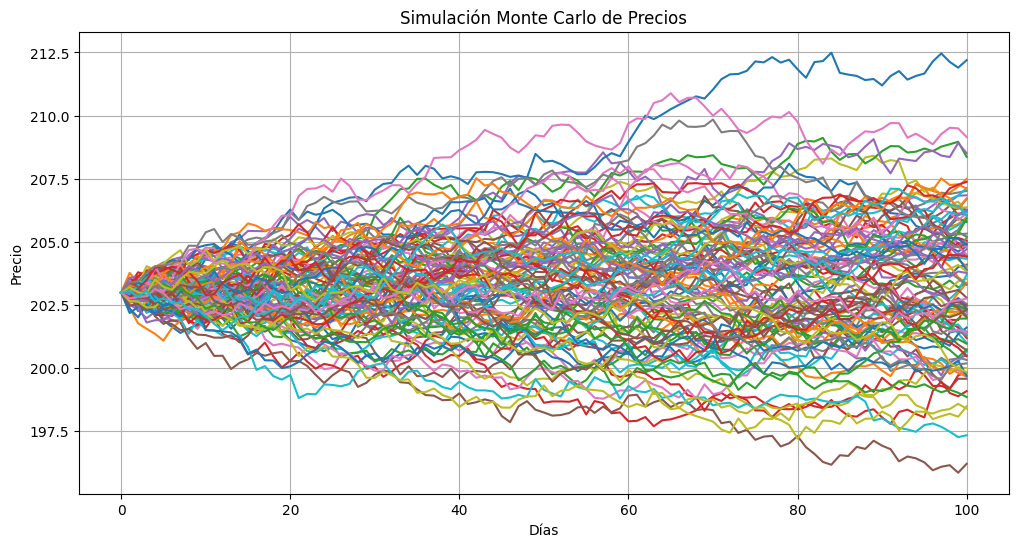

In [156]:
plt.figure(figsize=(12,6))

for simulacion in monte_carlo_simulaciones:
    plt.plot(simulacion)

plt.title('Simulación Monte Carlo de Precios')
plt.xlabel('Días')
plt.ylabel('Precio')
plt.grid(True)

plt.show()

#Predicción precio día siguiente

In [157]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [158]:
# Se extrae la última columna de los precios simulados
ultima_columna = monte_carlo_simulaciones_df.iloc[:,-1]
print(ultima_columna)

0      202.990005
1      203.053234
2      202.807281
3      203.061723
4      202.635141
          ...    
96     206.600174
97     206.743227
98     206.449645
99     206.432403
100    206.016509
Name: 99, Length: 101, dtype: float64


In [159]:
#Precio de cierre número 100
precio_cien = df['Close'][-101]
print(f"El precio de cierre número cien es: $ {precio_cien: .2f}")

El precio de cierre número cien es: $  198.46


/tmp/ipykernel_15945/3328606284.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precio_cien = df['Close'][-101]


In [160]:
#Calcular Ganancias / Pérdidas

Ganancia_Pérdida = []
for precio in ultima_columna:
    ganancia_perdida = precio - precio_cien
    Ganancia_Pérdida.append(ganancia_perdida)

In [170]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T
print(Ganancia_Pérdida)

            0
0    4.527481
1    4.590709
2    4.344757
3    4.599198
4    4.172616
..        ...
96   8.137649
97   8.280703
98   7.987121
99   7.969878
100  7.553985

[101 rows x 1 columns]


In [162]:
#Contar %Ganancias y %Pérdidas si el precio de compra es lo que vale el precio de cierre número cien
if isinstance(Ganancia_Pérdida, list):
    Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T

Ganancia = (Ganancia_Pérdida > 0).sum().sum()
Perdida = (Ganancia_Pérdida < 0).sum().sum()

# Obtener el número total de simulaciones
num_simulaciones = Ganancia_Pérdida.size

# Calcular porcentajes
porcentaje_ganancia = (Ganancia / num_simulaciones) * 100
porcentaje_perdida = (Perdida / num_simulaciones) * 100

print(f"Número de simulaciones con ganancia: {Ganancia} ({porcentaje_ganancia:.2f} %)")
print(f"Número de simulaciones con pérdida: {Perdida} ({porcentaje_perdida:.2f} %)")
print(f"Número total de simulaciones: {num_simulaciones}")

Número de simulaciones con ganancia: 101 (100.00 %)
Número de simulaciones con pérdida: 0 (0.00 %)
Número total de simulaciones: 101


In [163]:
#Ganancia potencial
Ganancia_potencial = Ganancia_Pérdida.mean(axis=1).iloc[0]
print(f"Ganancia Potencial: $ {Ganancia_potencial: .4f}")

Ganancia Potencial: $  6.1614


In [164]:
#Precio Potencial
Precio_potencial = precio_cien + Ganancia_potencial
print(f"Precio Potencial: $ {Precio_potencial: .4f}")

Precio Potencial: $  204.6240


##Estadísticos de Bondad de Ajuste

In [184]:
#Obtener datos
hoy = yf.download('GMEXICOB.MX', start='2026-06-29', end ='2026-06-30')

/tmp/ipykernel_15945/1590919340.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hoy = yf.download('GMEXICOB.MX', start='2026-06-29', end ='2026-06-30')
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['GMEXICOB.MX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2026-06-29 -> 2026-06-30)')


In [180]:
# Eliminar nivel del ticker
hoy.columns = hoy.columns.droplevel(1)

In [181]:
Precio_hoy = hoy['Close']
print(Precio_hoy)

Series([], Name: Close, dtype: float64)


In [168]:
comparacion = pd.DataFrame({
    "Real": Precio_hoy,
    "Pronosticado": Precio_potencial
})

print(comparacion)

Empty DataFrame
Columns: [Real, Pronosticado]
Index: []


###Error Cuadrático Medio (RMSE)


In [188]:
today= 201.179993

In [190]:
rmse = np.sqrt(mean_squared_error([today], [Precio_potencial]))
print(f"RMSE Monte Carlo: {rmse:.4f}")

RMSE Monte Carlo: 3.4440


In [194]:
rmse_porcentaje = (rmse / today) * 100
print(f"% RMSE Monte Carlo: {rmse_porcentaje:.4f} %")

% RMSE Monte Carlo: 1.7119 %


###Error Cuadrático Medio (MAE)

In [195]:
mae = mean_absolute_error([today], [Precio_potencial])

print(f"MAE Monte Carlo: {mae:.4f}")

MAE Monte Carlo: 3.4440


In [196]:
mae_porcentaje = (mae / today) * 100
print(f"% MAE Monte Carlo: {mae_porcentaje:.4f} %")

% MAE Monte Carlo: 1.7119 %


###Error Porcentual Absoluto Medio (MAPE)

In [197]:
# Using scikit-learn
mape = mean_absolute_percentage_error([today], [Precio_potencial]) * 100
print(f"MAPE: {mape:.4f}%")

MAPE: 1.7119%
